In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# 1. Hardware Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 5

# 3. Download & Prepare MNIST Dataset
# Transforms convert images to PyTorch Tensors and normalize them around 0
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST standard mean and std dev
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# 4. Build a Convolutional Neural Network (CNN)
class DigitClassifier(nn.Module):
    def __init__(self):
        super(DigitClassifier, self).__init__()
        # Conv layer 1: 1 input channel (grayscale), 32 output filters, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Conv layer 2: 32 input filters, 64 output filters, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Max pooling downsamples image size by half (28x28 -> 14x14 -> 7x7)
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 outputs correspond to digits 0-9
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x))) # State: 32 filters, 14x14 shape
        x = self.pool(self.relu(self.conv2(x))) # State: 64 filters, 7x7 shape
        x = x.view(-1, 64 * 7 * 7)               # Flatten into a 1D vector
        x = self.relu(self.fc1(x))
        x = self.fc2(x)                         # Raw logits output (No Softmax needed with CrossEntropyLoss)
        return x

model = DigitClassifier().to(device)

# 5. Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 6. Training Loop
print("\n--- Starting Training ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f}")

# 7. Final Evaluation (Test Accuracy)
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n🎯 Final Test Accuracy: {accuracy:.2f}% (Target: >95%)")

# Save the model state for your Week 7-8 FGSM Adversarial Attacks
torch.save(model.state_dict(), "mnist_cnn.pth")
print("Model saved successfully as 'mnist_cnn.pth'!")


Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 405kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.10MB/s]



--- Starting Training ---
Epoch [1/5] | Train Loss: 0.1430
Epoch [2/5] | Train Loss: 0.0418
Epoch [3/5] | Train Loss: 0.0305
Epoch [4/5] | Train Loss: 0.0219
Epoch [5/5] | Train Loss: 0.0154

🎯 Final Test Accuracy: 99.05% (Target: >95%)
Model saved successfully as 'mnist_cnn.pth'!


In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define SimpleCNN (Model A)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(x)
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Define DeepCNN (Model B)
class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(128 * 3 * 3, 256)
        self.fc2   = nn.Linear(256, 10)
        self.relu  = nn.ReLU()
        self.bn1   = nn.BatchNorm2d(32)
        self.bn2   = nn.BatchNorm2d(64)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(-1, 128 * 3 * 3)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Load test data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
test_data   = datasets.MNIST('./data', train=False, transform=transform)
train_data  = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_loader = DataLoader(test_data,  batch_size=64, shuffle=False)
train_loader= DataLoader(train_data, batch_size=64, shuffle=True)

# Load model A from saved file
model_a = SimpleCNN().to(device)
model_a.load_state_dict(torch.load("mnist_cnn.pth", map_location=device))
model_a.eval()
print("Model A (SimpleCNN) loaded ✓")

# Model B needs to be trained fresh since only one was saved
model_b = DeepCNN().to(device)
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training Model B (DeepCNN)...")
model_b.train()
for epoch in range(5):
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_b.zero_grad()
        outputs = model_b(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_b.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 | Loss: {total_loss/len(train_loader):.4f}")

torch.save(model_b.state_dict(), "deep_cnn.pth")
print("Model B (DeepCNN) trained and saved ✓")

# Quick accuracy check on both
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
    return correct / len(loader.dataset) * 100

acc_a = evaluate(model_a, test_loader)
acc_b = evaluate(model_b, test_loader)
print(f"\nSimpleCNN accuracy: {acc_a:.2f}%")
print(f"DeepCNN accuracy:   {acc_b:.2f}%")

Model A (SimpleCNN) loaded ✓
Training Model B (DeepCNN)...
Epoch 1/5 | Loss: 0.1448
Epoch 2/5 | Loss: 0.0538
Epoch 3/5 | Loss: 0.0403
Epoch 4/5 | Loss: 0.0347
Epoch 5/5 | Loss: 0.0300
Model B (DeepCNN) trained and saved ✓

SimpleCNN accuracy: 95.33%
DeepCNN accuracy:   99.01%


SimpleCNN under FGSM attack:
  epsilon=0.00 → accuracy=95.33%
  epsilon=0.05 → accuracy=92.24%
  epsilon=0.10 → accuracy=88.93%
  epsilon=0.15 → accuracy=84.42%
  epsilon=0.20 → accuracy=79.35%
  epsilon=0.25 → accuracy=73.73%
  epsilon=0.30 → accuracy=67.74%

DeepCNN under FGSM attack:
  epsilon=0.00 → accuracy=99.01%
  epsilon=0.05 → accuracy=98.22%
  epsilon=0.10 → accuracy=97.00%
  epsilon=0.15 → accuracy=95.28%
  epsilon=0.20 → accuracy=92.93%
  epsilon=0.25 → accuracy=89.54%
  epsilon=0.30 → accuracy=85.01%


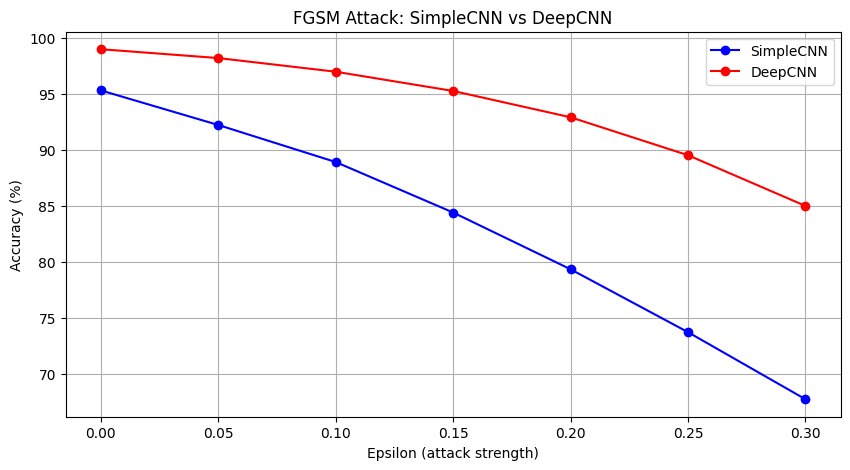

Chart saved as fgsm_comparison.png


In [4]:
import matplotlib.pyplot as plt

# FGSM attack function
def fgsm_attack(image, epsilon, gradient):
    # Calculate correct clamp bounds for normalized MNIST
    # Original range [0,1] normalized with mean=0.1307, std=0.3081
    min_val = (0 - 0.1307) / 0.3081   # = -0.4243
    max_val = (1 - 0.1307) / 0.3081   # =  2.8215

    sign_gradient = gradient.sign()
    attacked = image + epsilon * sign_gradient
    attacked = torch.clamp(attacked, min_val, max_val)  # correct bounds
    return attacked

# Evaluate model accuracy under FGSM attack
def evaluate_under_attack(model, loader, epsilon):
    model.eval()
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        images.requires_grad = True
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()
        attacked_images = fgsm_attack(images, epsilon, images.grad.data)
        with torch.no_grad():
            outputs = model(attacked_images)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return correct / total * 100

# Run epsilon sweep on BOTH models
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

print("SimpleCNN under FGSM attack:")
results_a = []
for eps in epsilons:
    acc = evaluate_under_attack(model_a, test_loader, eps)
    results_a.append(acc)
    print(f"  epsilon={eps:.2f} → accuracy={acc:.2f}%")

print("\nDeepCNN under FGSM attack:")
results_b = []
for eps in epsilons:
    acc = evaluate_under_attack(model_b, test_loader, eps)
    results_b.append(acc)
    print(f"  epsilon={eps:.2f} → accuracy={acc:.2f}%")

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(epsilons, results_a, 'b-o', label='SimpleCNN')
plt.plot(epsilons, results_b, 'r-o', label='DeepCNN')
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("Accuracy (%)")
plt.title("FGSM Attack: SimpleCNN vs DeepCNN")
plt.legend()
plt.grid(True)
plt.savefig("fgsm_comparison.png")
plt.show()
print("Chart saved as fgsm_comparison.png")

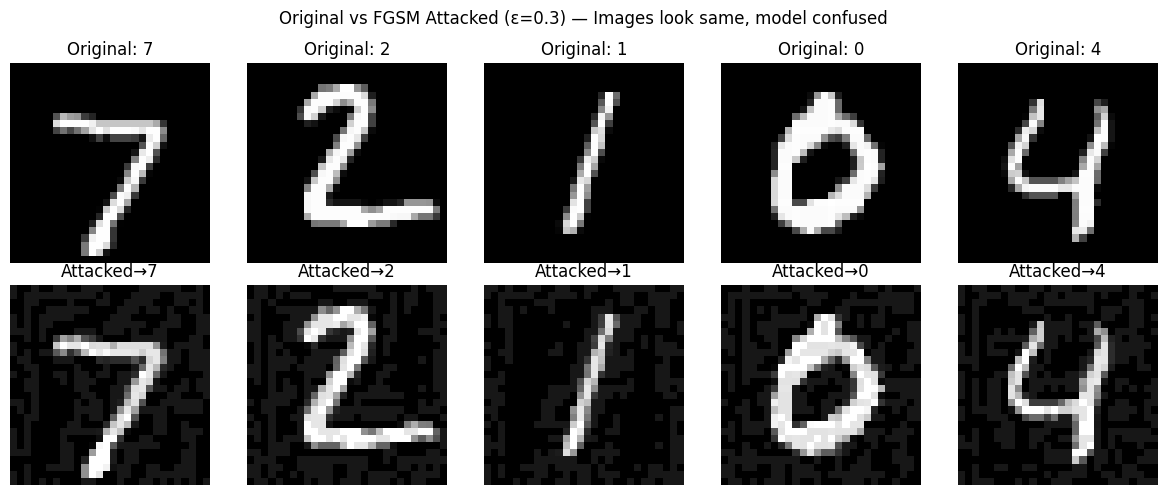

Visualization saved as fgsm_visual.png


In [5]:
# Visualize original vs attacked images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    image, label = test_data[i]
    image = image.unsqueeze(0).to(device)
    image.requires_grad = True

    output = model_a(image)
    loss = nn.CrossEntropyLoss()(output, torch.tensor([label]).to(device))
    model_a.zero_grad()
    loss.backward()

    attacked = fgsm_attack(image, 0.3, image.grad.data)

    # Original image
    axes[0][i].imshow(image.squeeze().cpu().detach().numpy(), cmap='gray')
    axes[0][i].set_title(f"Original: {label}")
    axes[0][i].axis('off')

    # Attacked image
    pred = model_a(attacked).argmax(1).item()
    axes[1][i].imshow(attacked.squeeze().cpu().detach().numpy(), cmap='gray')
    axes[1][i].set_title(f"Attacked→{pred}")
    axes[1][i].axis('off')

plt.suptitle("Original vs FGSM Attacked (ε=0.3) — Images look same, model confused")
plt.tight_layout()
plt.savefig("fgsm_visual.png")
plt.show()
print("Visualization saved as fgsm_visual.png")

In [6]:
# Install ART
!pip install adversarial-robustness-toolbox -q

import numpy as np
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod
from art.defences.trainer import AdversarialTrainer

# Prepare numpy data for ART
x_train = train_data.data.numpy().astype(np.float32) / 255.0
x_train = x_train[:, np.newaxis, :, :]  # add channel dimension
y_train = train_data.targets.numpy()

x_test = test_data.data.numpy().astype(np.float32) / 255.0
x_test = x_test[:, np.newaxis, :, :]
y_test = test_data.targets.numpy()

print(f"Train shape: {x_train.shape}")
print(f"Test shape:  {x_test.shape}")
print("Data prepared for ART ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.3 MB/s eta 0:00:00
Train shape: (60000, 1, 28, 28)
Test shape:  (10000, 1, 28, 28)
Data prepared for ART ✓


In [7]:
import torch.optim as optim

# Fresh copy of SimpleCNN for adversarial training
model_a_defended = SimpleCNN().to(device)
model_a_defended.load_state_dict(torch.load("mnist_cnn.pth", map_location=device))

optimizer_defended = optim.Adam(model_a_defended.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Wrap in ART classifier
classifier_a = PyTorchClassifier(
    model=model_a_defended,
    loss=criterion,
    optimizer=optimizer_defended,
    input_shape=(1, 28, 28),
    nb_classes=10,
    clip_values=(0.0, 1.0),
    device_type="gpu"
)

# Create FGSM attack for ART
attack_art = FastGradientMethod(estimator=classifier_a, eps=0.3)

# Adversarial training — trains on mix of clean + attacked images
trainer = AdversarialTrainer(classifier_a, attacks=attack_art, ratio=0.5)

print("Starting adversarial training on SimpleCNN...")
print("This will take 5-10 minutes...")
trainer.fit(
    x_train,
    y_train,
    nb_epochs=5,
    batch_size=64
)
print("Adversarial training complete ✓")

Starting adversarial training on SimpleCNN...
This will take 5-10 minutes...


Precompute adv samples:   0%|          | 0/1 [00:00<?, ?it/s]

Adversarial training epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Adversarial training complete ✓


In [8]:
# Evaluate defended model vs undefended model
# Generate attacked test samples using ART
x_test_attacked = attack_art.generate(x=x_test[:1000])

# Accuracy of UNDEFENDED model on clean images
pred_clean_undefended = classifier_a.predict(x_test[:1000])
acc_clean_undefended = np.mean(np.argmax(pred_clean_undefended, axis=1) == y_test[:1000]) * 100

# Accuracy of UNDEFENDED model under attack
results_a_03 = evaluate_under_attack(model_a, test_loader, 0.3)

# Accuracy of DEFENDED model on clean images
pred_clean_defended = classifier_a.predict(x_test[:1000])
acc_clean_defended = np.mean(np.argmax(pred_clean_defended, axis=1) == y_test[:1000]) * 100

# Accuracy of DEFENDED model under attack
pred_attacked_defended = classifier_a.predict(x_test_attacked)
acc_attacked_defended = np.mean(np.argmax(pred_attacked_defended, axis=1) == y_test[:1000]) * 100

# Print full benchmark table
print("=" * 60)
print("ADVERSARIAL ROBUSTNESS BENCHMARK RESULTS")
print("=" * 60)
print(f"\n{'Model':<30} {'Clean':>10} {'ε=0.3 Attack':>14}")
print("-" * 60)
print(f"{'SimpleCNN (no defense)':<30} {results_a[0]:>9.2f}% {results_a[-1]:>13.2f}%")
print(f"{'SimpleCNN + ART defense':<30} {acc_clean_defended:>9.2f}% {acc_attacked_defended:>13.2f}%")
print(f"{'DeepCNN (no defense)':<30} {results_b[0]:>9.2f}% {results_b[-1]:>13.2f}%")
print("-" * 60)
print("\nConclusion:")
print(f"ART defense improved attack resistance by {acc_attacked_defended - results_a[-1]:.2f}%")

# Save results to CSV
import pandas as pd
results_df = pd.DataFrame({
    "Model": ["SimpleCNN", "SimpleCNN+ART", "DeepCNN"],
    "Clean_Accuracy": [results_a[0], acc_clean_defended, results_b[0]],
    "Attack_eps_0.3": [results_a[-1], acc_attacked_defended, results_b[-1]]
})
results_df.to_csv("benchmark_results.csv", index=False)
print("\nResults saved to benchmark_results.csv ✓")
print(results_df.to_string(index=False))

ADVERSARIAL ROBUSTNESS BENCHMARK RESULTS

Model                               Clean   ε=0.3 Attack
------------------------------------------------------------
SimpleCNN (no defense)             95.33%         67.74%
SimpleCNN + ART defense            99.00%         95.90%
DeepCNN (no defense)               99.01%         85.01%
------------------------------------------------------------

Conclusion:
ART defense improved attack resistance by 28.16%

Results saved to benchmark_results.csv ✓
        Model  Clean_Accuracy  Attack_eps_0.3
    SimpleCNN           95.33           67.74
SimpleCNN+ART           99.00           95.90
      DeepCNN           99.01           85.01


In [9]:
# Download all result files to your local machine
from google.colab import files

files.download("fgsm_comparison.png")
files.download("fgsm_visual.png")
files.download("benchmark_results.csv")
files.download("mnist_cnn.pth")
files.download("deep_cnn.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>